Overfitting diagnostics: Train-vs-CV Gap & Learning Curves

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="darkgrid")

Rebuilding the pipeline


In [5]:
BASE = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project'
df = pd.read_csv(os.path.join(BASE, 'data', 'kepler_clean.csv'))

TARGET = 'koi_disposition'
df_model = df[df[TARGET].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

KEY_FEATURES = [
    'koi_period', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg', 
    'koi_srad', 'koi_score', 'koi_depth',
    'koi_duration', 'koi_impact',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]

X = df_model[KEY_FEATURES]
y_raw = df_model[TARGET]

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Label Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Total rows: {len(X):,}")

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

Label Encoding: {'CONFIRMED': np.int64(0), 'FALSE POSITIVE': np.int64(1)}
Total rows: 6,203


Train vs CV gap (the overfitting check)

In [6]:
cv_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("PHASE 7: Train vs CV Score (overfittting check)")
print("-" * 70)

gap_results = {}

for name, model in cv_models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    scores = cross_validate(
        pipe, X_imp, y, cv=skf,
        scoring='roc_auc',
        return_train_score=True,
        n_jobs=-1
    )

    train_mean, train_std = scores['train_score'].mean(), scores['train_score'].std()
    cv_mean, cv_std = scores['test_score'].mean(), scores['train_score'].std()
    gap = train_mean - cv_mean

    gap_results[name] = {
        'train_auc': train_mean, 'train_std': train_std,
        'cv_auc': cv_mean, 'cv_std': cv_std, 'gap': gap
    }

    print(f"\n{name}")
    print(f" Train AUC: {train_mean:.4f} ± {train_std:.4f}")
    print(f" CV AUC: {cv_mean:.4f} ± {cv_std:.4f}")
    print(f" Gap: {gap:.4f}"
          f'⚠ Possible overfitting' if gap > 0.02 else '✓ Healthy')

print("\n" + "-" * 70)
print("Rule of thumb: gap > ~0.02-0.02 AUC on a task this size is worth investigating")

PHASE 7: Train vs CV Score (overfittting check)
----------------------------------------------------------------------

Random Forest
 Train AUC: 1.0000 ± 0.0000
 CV AUC: 0.9987 ± 0.0000
✓ Healthy

XGBoost
 Train AUC: 1.0000 ± 0.0000
 CV AUC: 0.9989 ± 0.0000
✓ Healthy

Gradient Boosting
 Train AUC: 1.0000 ± 0.0000
 CV AUC: 0.9991 ± 0.0000
✓ Healthy

----------------------------------------------------------------------
Rule of thumb: gap > ~0.02-0.02 AUC on a task this size is worth investigating


LEARNING CURVES
----------------------------------------------------------------------


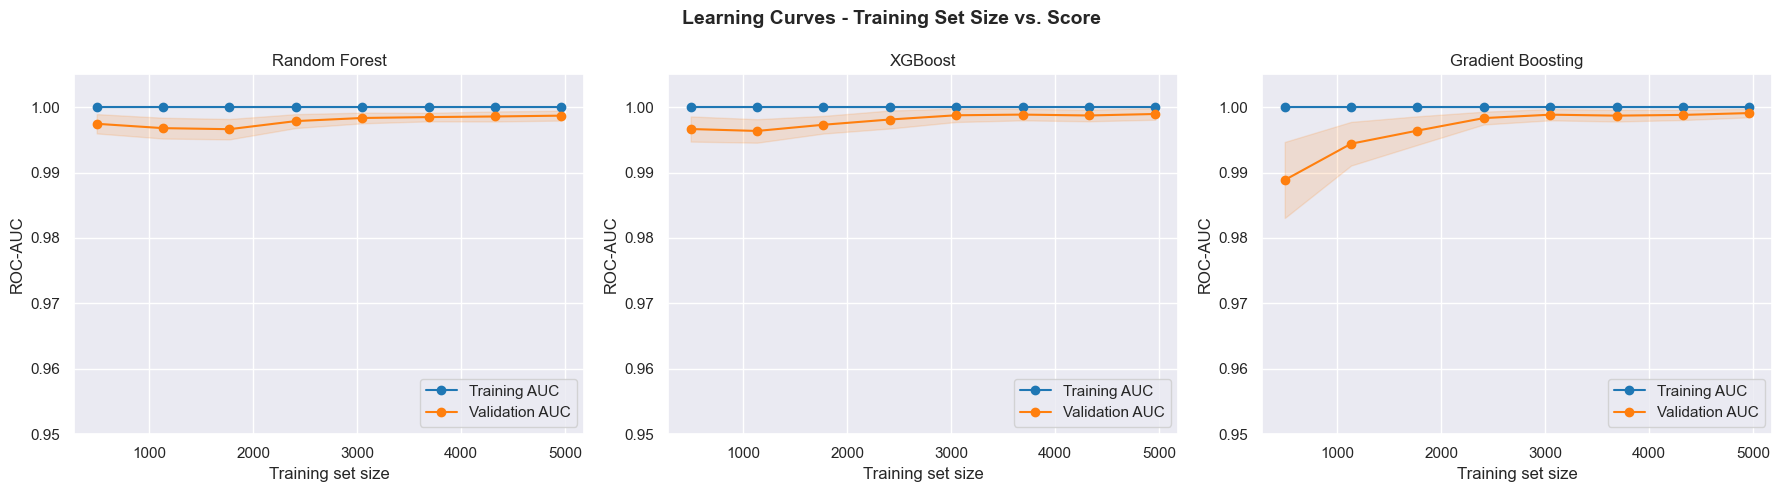

In [11]:
print("LEARNING CURVES")
print("-" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, cv_models.items()):
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_imp, y,
        cv=skf, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=42
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='tab:blue', label='Training AUC')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='tab:blue')

    ax.plot(train_sizes, val_mean, 'o-', color='tab:orange', label='Validation AUC')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='tab:orange')

    ax.set_title(name)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('ROC-AUC')
    ax.legend(loc='lower right')
    ax.set_ylim(0.95, 1.005)

plt.suptitle('Learning Curves - Training Set Size vs. Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p7_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()